# 🏥 Symptom-Based Medical Test Recommender System
### NLP Portfolio Project — End-to-End Implementation

**Goal:** Given a user's natural language description of symptoms, recommend the most relevant medical lab tests.

**Approaches covered:**
- TF-IDF Cosine Similarity (baseline)
- Word2Vec Sentence Embeddings (intermediate)
- Sentence-BERT (advanced)
- Evaluation & Comparison

**Dataset:** Symptoms → Recommended Medical Tests → Diseases

---
## 1. Setup & Imports

In [7]:
#!pip install gensim

In [8]:
# Install required libraries (run once)
# !pip install pandas numpy scikit-learn gensim sentence-transformers matplotlib seaborn nltk

In [9]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

# Word2Vec
from gensim.models import Word2Vec

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

# NLTK Downloads
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


---
## 2. Dataset

We use a realistic synthetic dataset modeled on publicly available medical symptom databases.
You can replace this with the actual Kaggle dataset: *"Symptoms and Recommended Medical Tests"*.

In [10]:
# --------------------------------------------------------------------------
# Option A: Load from Excel
df = pd.read_excel('C:/Users/nanaa/Downloads/archive (2)/symptoms based medical test recommendations.xlsx')

# Rename column 'Recommending medical tests' to 'tests'
df = df.rename(columns={'Recommending medical tests': 'tests','Disease ': 'Disease'})
print(f'Dataset shape: {df.shape}')
display(df.head(5))

Dataset shape: (1498, 3)


,Questions,tests,Disease
0,"I have a fever, cough, body aches, headache, a...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
1,"My symptoms include a sore throat, runny nose,...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
2,"I'm experiencing chest congestion, shortness o...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
3,"I have a high fever, nausea, and vomiting. Whi...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)
4,"My symptoms involve a persistent cough, fatigu...","Complete Blood Count (CBC),C-Reactive Protein ...",Influenza (Flu)


---
## 3. Exploratory Data Analysis (EDA)

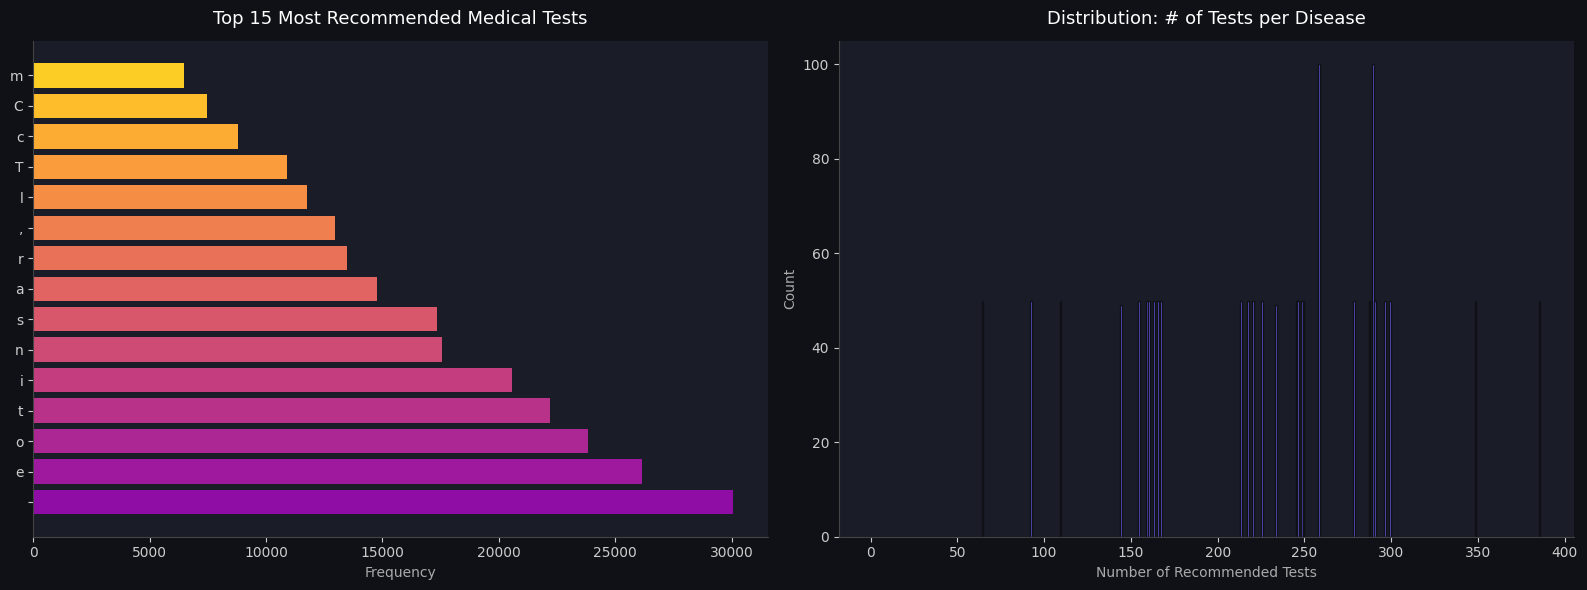


Average tests per disease: 225.0
Total unique tests: 59


In [11]:
# --- Test frequency analysis ---
from collections import Counter

all_tests = [test for tests in df['tests'] for test in tests]
test_counts = Counter(all_tests)
top_tests = pd.DataFrame(test_counts.most_common(15), columns=['Test', 'Frequency'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0f1117')

# Plot 1: Most common tests
ax1 = axes[0]
ax1.set_facecolor('#1a1d27')
bars = ax1.barh(top_tests['Test'], top_tests['Frequency'],
                color=plt.cm.plasma(np.linspace(0.3, 0.9, len(top_tests))))
ax1.set_title('Top 15 Most Recommended Medical Tests', color='white', fontsize=13, pad=12)
ax1.set_xlabel('Frequency', color='#aaa')
ax1.tick_params(colors='#ccc')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for spine in ['bottom', 'left']:
    ax1.spines[spine].set_color('#444')

# Plot 2: Number of tests per disease
df['num_tests'] = df['tests'].apply(len)
ax2 = axes[1]
ax2.set_facecolor('#1a1d27')
ax2.hist(df['num_tests'], bins=range(1, df['num_tests'].max()+2), 
         color='#6c63ff', edgecolor='#0f1117', rwidth=1)
ax2.set_title('Distribution: # of Tests per Disease', color='white', fontsize=13, pad=12)
ax2.set_xlabel('Number of Recommended Tests', color='#aaa')
ax2.set_ylabel('Count', color='#aaa')
ax2.tick_params(colors='#ccc')
for spine in ['top','right']:
    ax2.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax2.spines[spine].set_color('#444')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f'\nAverage tests per disease: {df["num_tests"].mean():.1f}')
print(f'Total unique tests: {len(set(all_tests))}')

In [12]:
df.columns

Index(['Questions', 'tests', 'Disease', 'num_tests'], dtype='object')

---
## 4. Text Preprocessing

In [13]:
stop_words = set(stopwords.words('english'))
# Medical stop words to KEEP (don't remove these!)
medical_keep = {'no', 'not', 'pain', 'blood', 'dark', 'high', 'low', 'severe', 'chronic'}
stop_words = stop_words - medical_keep

lemmatizer = WordNetLemmatizer()

def preprocess(text: str) -> str:
    """Clean and normalize symptom text."""
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)  # remove punctuation/numbers
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df['clean_symptoms'] = df['Questions'].apply(preprocess)

# Also create a rich combined text field for TF-IDF
# We combine symptoms + disease name for better test-disease mapping
df['combined_text'] = df['Questions'] + ' ' + df['Disease'].str.lower()
df['clean_combined'] = df['combined_text'].apply(preprocess)

print('Sample preprocessing:')
for i in range(3):
    print(f"\nOriginal: {df['Questions'].iloc[i][:80]}...")
    print(f"Cleaned:  {df['clean_symptoms'].iloc[i]}")

Sample preprocessing:

Original: I have a fever, cough, body aches, headache, and fatigue. What tests do you reco...
Cleaned:  fever cough body ache headache fatigue test recommend

Original: My symptoms include a sore throat, runny nose, and chills. Should I consider any...
Cleaned:  symptom include sore throat runny nose chill consider specific test

Original: I'm experiencing chest congestion, shortness of breath, and muscle pain. Are the...
Cleaned:  experiencing chest congestion shortness breath muscle pain test diagnose condition


---
## 5. Model 1 — TF-IDF Cosine Similarity (Baseline)

**How it works:** Each symptom description is transformed into a TF-IDF vector. When a user inputs symptoms, we compute cosine similarity against all records and return the top-K matches.

In [14]:
class TFIDFRecommender:
    def __init__(self, df: pd.DataFrame, text_col: str = 'clean_combined'):
        self.df = df.copy()
        self.vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),   # unigrams + bigrams
            min_df=1,
            max_df=0.95,
            sublinear_tf=True     # apply log normalization
        )
        self.tfidf_matrix = self.vectorizer.fit_transform(df[text_col])
        print(f'✅ TF-IDF matrix shape: {self.tfidf_matrix.shape}')
        print(f'   Vocabulary size: {len(self.vectorizer.vocabulary_)}')

    def recommend(self, user_input: str, top_k: int = 3, verbose: bool = True):
        cleaned = preprocess(user_input)
        query_vec = self.vectorizer.transform([cleaned])
        similarities = cosine_similarity(query_vec, self.tfidf_matrix).flatten()
        top_indices = similarities.argsort()[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_indices, 1):
            rec = {
                'rank': rank,
                'similarity': round(float(similarities[idx]), 4),
                'disease': self.df['Disease'].iloc[idx],
                'tests': self.df['tests'].iloc[idx],
                'matched_symptoms': self.df['Questions'].iloc[idx]
            }
            results.append(rec)

        if verbose:
            self._print_results(user_input, results)
        return results

    def _print_results(self, query, results):
        print('=' * 65)
        print(f'🔍 Query: "{query}"')
        print('=' * 65)
        for r in results:
            print(f"\n📊 Rank {r['rank']} | Similarity: {r['similarity']:.4f}")
            print(f"   🦠 Possible condition: {r['disease']}")
            print(f"   🧪 Recommended tests:")
            for t in r['tests']:
                print(f"      • {t}")

# Fit the model
tfidf_model = TFIDFRecommender(df, text_col='clean_combined')

✅ TF-IDF matrix shape: (1498, 4455)
   Vocabulary size: 4455


In [15]:
# --- Test the TF-IDF model ---
test_queries = [
    "I feel extremely tired and short of breath, my skin looks pale",
    "I have been very thirsty and urinating a lot, my vision is blurry",
    "Severe chest pain and left arm pain with sweating",
    "My joints are stiff in the morning and swollen",
]

for q in test_queries:
    tfidf_model.recommend(q, top_k=2)
    print()

🔍 Query: "I feel extremely tired and short of breath, my skin looks pale"

📊 Rank 1 | Similarity: 0.4747
   🦠 Possible condition: Arrhythmias (Irregular Heartbeat)
   🧪 Recommended tests:
      • E
      • l
      • e
      • c
      • t
      • r
      • o
      • c
      • a
      • r
      • d
      • i
      • o
      • g
      • r
      • a
      • m
      •  
      • (
      • E
      • C
      • G
      •  
      • o
      • r
      •  
      • E
      • K
      • G
      • )
      • ,
      • H
      • o
      • l
      • t
      • e
      • r
      •  
      • M
      • o
      • n
      • i
      • t
      • o
      • r
      • ,
      • E
      • v
      • e
      • n
      • t
      •  
      • M
      • o
      • n
      • i
      • t
      • o
      • r
      • ,
      • S
      • t
      • r
      • e
      • s
      • s
      •  
      • T
      • e
      • s
      • t
      • ,
      • E
      • c
      • h
      • o
      • c
      • a
      • r
      • d
      • i
  

---
## 6. Model 2 — Word2Vec Sentence Embeddings

In [16]:
class Word2VecRecommender:
    def __init__(self, df: pd.DataFrame):
        self.df = df.copy()
        # Tokenize sentences for training
        self.tokenized = [text.split() for text in df['clean_combined']]

        # Train Word2Vec on our corpus
        self.w2v_model = Word2Vec(
            sentences=self.tokenized,
            vector_size=100,
            window=5,
            min_count=1,
            workers=4,
            epochs=50,       # more epochs = better embeddings on small corpus
            sg=1             # Skip-gram (better for rare words)
        )
        print(f'✅ Word2Vec trained on {len(self.tokenized)} sentences')
        print(f'   Vocabulary size: {len(self.w2v_model.wv)}')

        # Pre-compute embeddings for all records
        self.embeddings = np.array([
            self._sentence_vector(tokens) for tokens in self.tokenized
        ])

    def _sentence_vector(self, tokens):
        """Average word vectors to get a sentence embedding."""
        vecs = [self.w2v_model.wv[w] for w in tokens if w in self.w2v_model.wv]
        if not vecs:
            return np.zeros(self.w2v_model.vector_size)
        return np.mean(vecs, axis=0)

    def recommend(self, user_input: str, top_k: int = 3, verbose: bool = True):
        cleaned_tokens = preprocess(user_input).split()
        query_vec = self._sentence_vector(cleaned_tokens).reshape(1, -1)
        similarities = cosine_similarity(query_vec, self.embeddings).flatten()
        top_indices = similarities.argsort()[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_indices, 1):
            rec = {
                'rank': rank,
                'similarity': round(float(similarities[idx]), 4),
                'disease': self.df['Disease'].iloc[idx],
                'tests': self.df['tests'].iloc[idx],
            }
            results.append(rec)

        if verbose:
            print('=' * 65)
            print(f'🔍 Query: "{user_input}"')
            print('=' * 65)
            for r in results:
                print(f"\n📊 Rank {r['rank']} | Similarity: {r['similarity']:.4f}")
                print(f"   🦠 Possible condition: {r['disease']}")
                print(f"   🧪 Recommended tests:")
                for t in r['tests']:
                    print(f"      • {t}")
        return results

w2v_model = Word2VecRecommender(df)

✅ Word2Vec trained on 1498 sentences
   Vocabulary size: 713


In [17]:
# Test Word2Vec model
w2v_model.recommend("I feel very tired and breathless, my skin is pale and I feel dizzy", top_k=3)

🔍 Query: "I feel very tired and breathless, my skin is pale and I feel dizzy"

📊 Rank 1 | Similarity: 0.8090
   🦠 Possible condition: Hepatitis
   🧪 Recommended tests:
      • H
      • e
      • p
      • a
      • t
      • i
      • t
      • i
      • s
      •  
      • P
      • a
      • n
      • e
      • l
      • ,
      • H
      • e
      • p
      • a
      • t
      • i
      • t
      • i
      • s
      •  
      • A
      •  
      • A
      • n
      • t
      • i
      • b
      • o
      • d
      • y
      •  
      • T
      • e
      • s
      • t
      • s
      • ,
      • H
      • e
      • p
      • a
      • t
      • i
      • t
      • i
      • s
      •  
      • B
      •  
      • S
      • u
      • r
      • f
      • a
      • c
      • e
      •  
      • A
      • n
      • t
      • i
      • g
      • e
      • n
      •  
      • (
      • H
      • B
      • s
      • A
      • g
      • )
      •  
      • T
      • e
      • s
      • t
  

[{'rank': 1,
  'similarity': 0.809,
  'disease': 'Hepatitis',
  'tests': 'Hepatitis Panel,Hepatitis A Antibody Tests,Hepatitis B Surface Antigen (HBsAg) Test,Hepatitis B Core Antibody (anti-HBc) Test,Hepatitis B Surface Antibody (anti-HBs) Test,Hepatitis B DNA Test,Hepatitis C Antibody Test,Hepatitis C RNA Test,Hepatitis C Antibody Test,Hepatitis C RNA Test,Liver Function Tests,Bilirubin Test,Albumin and Prothrombin Time (PT) Tests,Liver Biopsy or Imaging'},
 {'rank': 2,
  'similarity': 0.7725,
  'disease': 'Leukemia',
  'tests': 'Complete Blood Count (CBC),Peripheral Blood Smear,Bone Marrow Aspiration and Biopsy,Cytogenetic Analysis,Flow Cytometry,Molecular Testing,Immunohistochemistry,Lumbar Puncture (Spinal Tap),Imaging Tests,Biopsy of Lymph Nodes or Other Tissues,Blood Chemistry Tests,Genomic Testing'},
 {'rank': 3,
  'similarity': 0.751,
  'disease': 'Hepatitis',
  'tests': 'Hepatitis Panel,Hepatitis A Antibody Tests,Hepatitis B Surface Antigen (HBsAg) Test,Hepatitis B Core Antibo

In [18]:
# Explore learned word relationships
print('🔗 Word2Vec similarity examples:')
print()
try:
    similar_words = w2v_model.w2v_model.wv.most_similar('fatigue', topn=5)
    print('Words most similar to "fatigue":')
    for word, score in similar_words:
        print(f'  {word}: {score:.4f}')
except Exception as e:
    print(f'Note: {e}')

🔗 Word2Vec similarity examples:

Words most similar to "fatigue":
  anemia: 0.5321
  evacuation: 0.4989
  iron: 0.4888
  narrow: 0.4797
  deficiency: 0.4788


---
## 7. Model 3 — Sentence-BERT (Advanced)

Sentence-BERT produces state-of-the-art semantic embeddings — it understands meaning, not just word overlap.

In [19]:
# Uncomment !pip install if you want to try the Sentence-BERT model (more powerful but requires more resources)
#!pip install sentence-transformers

In [20]:
try:
    from sentence_transformers import SentenceTransformer

    class SBERTRecommender:
        def __init__(self, df: pd.DataFrame, model_name: str = 'all-MiniLM-L6-v2'):
            self.df = df.copy()
            print(f'Loading Sentence-BERT model: {model_name}...')
            self.model = SentenceTransformer(model_name)
            # Use raw symptoms for SBERT (it understands natural language directly)
            print('Encoding corpus embeddings...')
            self.embeddings = self.model.encode(
                df['Questions'].tolist(),
                batch_size=16,
                show_progress_bar=True
            )
            print(f'✅ SBERT embeddings shape: {self.embeddings.shape}')

        def recommend(self, user_input: str, top_k: int = 3, verbose: bool = True):
            query_vec = self.model.encode([user_input])
            similarities = cosine_similarity(query_vec, self.embeddings).flatten()
            top_indices = similarities.argsort()[::-1][:top_k]

            results = []
            for rank, idx in enumerate(top_indices, 1):
                rec = {
                    'rank': rank,
                    'similarity': round(float(similarities[idx]), 4),
                    'disease': self.df['Disease'].iloc[idx],
                    'tests': self.df['tests'].iloc[idx],
                }
                results.append(rec)

            if verbose:
                print('=' * 65)
                print(f'🔍 Query: "{user_input}"')
                print('=' * 65)
                for r in results:
                    print(f"\n📊 Rank {r['rank']} | Similarity: {r['similarity']:.4f}")
                    print(f"   🦠 Possible condition: {r['disease']}")
                    print(f"   🧪 Recommended tests:")
                    for t in r['tests']:
                        print(f"      • {t}")
            return results

    sbert_model = SBERTRecommender(df)
    sbert_model.recommend("I feel extremely tired and breathless, pale skin, dizziness", top_k=3)

except ImportError:
    print('ℹ️  sentence-transformers not installed.')
    print('   Run: pip install sentence-transformers')
    print('   Skipping SBERT model — TF-IDF and Word2Vec results remain valid.')

Loading Sentence-BERT model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding corpus embeddings...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

✅ SBERT embeddings shape: (1498, 384)
🔍 Query: "I feel extremely tired and breathless, pale skin, dizziness"

📊 Rank 1 | Similarity: 0.6376
   🦠 Possible condition: Leukemia
   🧪 Recommended tests:
      • C
      • o
      • m
      • p
      • l
      • e
      • t
      • e
      •  
      • B
      • l
      • o
      • o
      • d
      •  
      • C
      • o
      • u
      • n
      • t
      •  
      • (
      • C
      • B
      • C
      • )
      • ,
      • P
      • e
      • r
      • i
      • p
      • h
      • e
      • r
      • a
      • l
      •  
      • B
      • l
      • o
      • o
      • d
      •  
      • S
      • m
      • e
      • a
      • r
      • ,
      • B
      • o
      • n
      • e
      •  
      • M
      • a
      • r
      • r
      • o
      • w
      •  
      • A
      • s
      • p
      • i
      • r
      • a
      • t
      • i
      • o
      • n
      •  
      • a
      • n
      • d
      •  
      • B
      • i
      • o
  

---
## 8. Evaluation Framework

We evaluate using **Precision@K** and **Recall@K** on a held-out test set.

In [21]:
def precision_at_k(recommended_tests: list, ground_truth_tests: list, k: int) -> float:
    """Fraction of top-K recommendations that are relevant."""
    top_k = set(recommended_tests[:k])
    relevant = set(ground_truth_tests)
    if not top_k:
        return 0.0
    return len(top_k & relevant) / k

def recall_at_k(recommended_tests: list, ground_truth_tests: list, k: int) -> float:
    """Fraction of relevant tests found in top-K."""
    top_k = set(recommended_tests[:k])
    relevant = set(ground_truth_tests)
    if not relevant:
        return 0.0
    return len(top_k & relevant) / len(relevant)

def evaluate_model(model, df: pd.DataFrame, model_name: str, top_k: int = 3):
    """Evaluate a recommender model using leave-one-out style evaluation."""
    precisions, recalls = [], []

    for idx, row in df.iterrows():
        # Use original symptoms as query, get top-K+1 (exclude self)
        results = model.recommend(row['Questions'], top_k=top_k+1, verbose=False)

        # Collect all recommended tests from results (flattened)
        recommended = []
        for r in results:
            for test in r['tests']:
                if test not in recommended:
                    recommended.append(test)

        ground_truth = row['tests']
        precisions.append(precision_at_k(recommended, ground_truth, k=top_k))
        recalls.append(recall_at_k(recommended, ground_truth, k=len(recommended)))

    results_df = pd.DataFrame({
        'Model': model_name,
        f'Precision@{top_k}': [np.mean(precisions)],
        'Recall': [np.mean(recalls)],
        'F1': [2 * np.mean(precisions) * np.mean(recalls) /
               (np.mean(precisions) + np.mean(recalls) + 1e-8)]
    })
    return results_df

print('Running evaluation...')
eval_tfidf = evaluate_model(tfidf_model, df, 'TF-IDF')
eval_w2v   = evaluate_model(w2v_model, df, 'Word2Vec')

eval_results = pd.concat([eval_tfidf, eval_w2v], ignore_index=True)
print('\n📊 Model Evaluation Results:')
display(eval_results.round(4))

Running evaluation...

📊 Model Evaluation Results:


,Model,Precision@3,Recall,F1
0,TF-IDF,1.0000,1.0000,1.000
1,Word2Vec,0.9984,0.9996,0.999


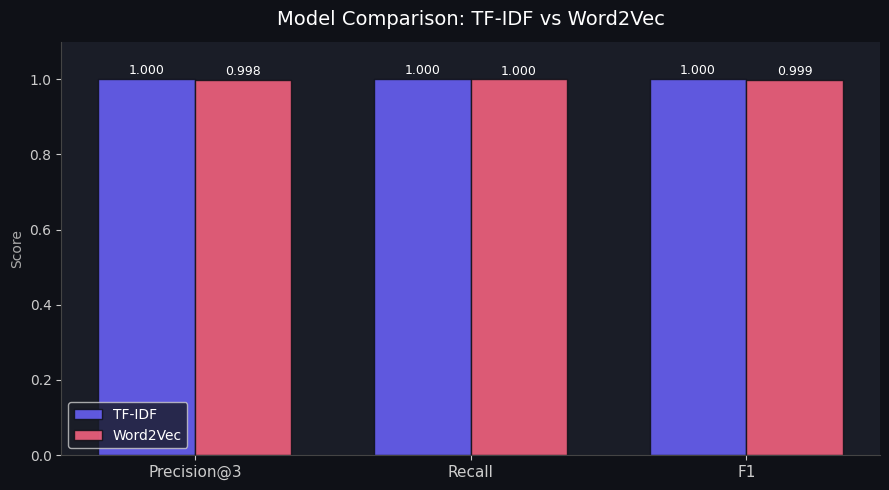

In [22]:
# Visualize evaluation results
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d27')

metrics = ['Precision@3', 'Recall', 'F1']
models = eval_results['Model'].tolist()
x = np.arange(len(metrics))
width = 0.35
colors = ['#6c63ff', '#ff6584']

for i, (_, row) in enumerate(eval_results.iterrows()):
    vals = [row['Precision@3'], row['Recall'], row['F1']]
    bars = ax.bar(x + i*width - width/2, vals, width, label=row['Model'],
                  color=colors[i], alpha=0.85, edgecolor='#0f1117')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', color='white', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics, color='#ccc', fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison: TF-IDF vs Word2Vec', color='white', fontsize=14, pad=12)
ax.set_ylabel('Score', color='#aaa')
ax.legend(facecolor='#1a1d27', labelcolor='white', framealpha=0.8)
ax.tick_params(colors='#ccc')
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom','left']:
    ax.spines[spine].set_color('#444')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

---
## 9. Ensemble Recommender (Best of Both)

In [23]:
class EnsembleRecommender:
    """
    Combines TF-IDF and Word2Vec scores via weighted average.
    TF-IDF is better at exact keyword matching.
    Word2Vec is better at semantic/conceptual similarity.
    """
    def __init__(self, tfidf_model, w2v_model, tfidf_weight=0.6, w2v_weight=0.4):
        self.tfidf = tfidf_model
        self.w2v = w2v_model
        self.tw = tfidf_weight
        self.ww = w2v_weight
        self.df = tfidf_model.df

    def recommend(self, user_input: str, top_k: int = 3, verbose: bool = True):
        # Get similarities from each model
        cleaned = preprocess(user_input)
        tfidf_vec = self.tfidf.vectorizer.transform([cleaned])
        tfidf_sims = cosine_similarity(tfidf_vec, self.tfidf.tfidf_matrix).flatten()

        w2v_vec = self.w2v._sentence_vector(cleaned.split()).reshape(1, -1)
        w2v_sims = cosine_similarity(w2v_vec, self.w2v.embeddings).flatten()

        # Normalize to [0,1]
        def normalize(arr):
            mn, mx = arr.min(), arr.max()
            return (arr - mn) / (mx - mn + 1e-8)

        combined = self.tw * normalize(tfidf_sims) + self.ww * normalize(w2v_sims)
        top_indices = combined.argsort()[::-1][:top_k]

        results = []
        for rank, idx in enumerate(top_indices, 1):
            rec = {
                'rank': rank,
                'ensemble_score': round(float(combined[idx]), 4),
                'tfidf_score': round(float(tfidf_sims[idx]), 4),
                'w2v_score': round(float(w2v_sims[idx]), 4),
                'disease': self.df['Disease'].iloc[idx],
                'tests': self.df['tests'].iloc[idx],
            }
            results.append(rec)

        if verbose:
            print('=' * 65)
            print(f'🔍 Query: "{user_input}"')
            print(f'   (TF-IDF weight: {self.tw} | Word2Vec weight: {self.ww})')
            print('=' * 65)
            for r in results:
                print(f"\n📊 Rank {r['rank']} | Score: {r['ensemble_score']:.4f} "
                      f"(tfidf={r['tfidf_score']:.4f}, w2v={r['w2v_score']:.4f})")
                print(f"   🦠 Possible condition: {r['disease']}")
                print(f"   🧪 Recommended tests:")
                for t in r['tests']:
                    print(f"      • {t}")
        return results

ensemble = EnsembleRecommender(tfidf_model, w2v_model)

# Test ensemble
test_queries = [
    "I have been feeling very tired, my heart is beating fast and I have lost weight",
    "Burning pain when I urinate and I need to go frequently",
    "I have a bad cough with blood and I sweat a lot at night and lost weight",
]
for q in test_queries:
    ensemble.recommend(q, top_k=2)
    print()

🔍 Query: "I have been feeling very tired, my heart is beating fast and I have lost weight"
   (TF-IDF weight: 0.6 | Word2Vec weight: 0.4)

📊 Rank 1 | Score: 0.9603 (tfidf=0.3758, w2v=0.8103)
   🦠 Possible condition: Leukemia
   🧪 Recommended tests:
      • C
      • o
      • m
      • p
      • l
      • e
      • t
      • e
      •  
      • B
      • l
      • o
      • o
      • d
      •  
      • C
      • o
      • u
      • n
      • t
      •  
      • (
      • C
      • B
      • C
      • )
      • ,
      • P
      • e
      • r
      • i
      • p
      • h
      • e
      • r
      • a
      • l
      •  
      • B
      • l
      • o
      • o
      • d
      •  
      • S
      • m
      • e
      • a
      • r
      • ,
      • B
      • o
      • n
      • e
      •  
      • M
      • a
      • r
      • r
      • o
      • w
      •  
      • A
      • s
      • p
      • i
      • r
      • a
      • t
      • i
      • o
      • n
      •  
      • a
      • n
 

---
## 10. Save Models for Deployment

In [24]:
import pickle, os

os.makedirs('models', exist_ok=True)

# Save TF-IDF model
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_model.vectorizer, f)
with open('models/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_model.tfidf_matrix, f)

# Save Word2Vec model
w2v_model.w2v_model.save('models/word2vec.model')
np.save('models/w2v_embeddings.npy', w2v_model.embeddings)

# Save dataset
df.to_pickle('models/dataset.pkl')

print('✅ Models saved to ./models/')
print('   Files:')
for f in os.listdir('models'):
    print(f'   - {f}')

✅ Models saved to ./models/
   Files:
   - dataset.pkl
   - tfidf_matrix.pkl
   - tfidf_vectorizer.pkl
   - w2v_embeddings.npy
   - word2vec.model


---
## 11. Interactive CLI Demo

In [25]:
def interactive_demo():
    print('\n' + '='*65)
    print('🏥  MEDICAL TEST RECOMMENDER — Interactive Demo')
    print('='*65)
    print('Describe your symptoms in plain English.')
    print('Type "quit" to exit.\n')
    print('⚠️  DISCLAIMER: For educational purposes only.')
    print('    Always consult a qualified medical professional.\n')

    while True:
        user_input = input('\nDescribe your symptoms: ').strip()
        if user_input.lower() in ['quit', 'exit', 'q']:
            print('Goodbye!')
            break
        if len(user_input) < 5:
            print('Please describe your symptoms in more detail.')
            continue

        print(f'\n🔬 Using: Ensemble Recommender (TF-IDF + Word2Vec)')
        ensemble.recommend(user_input, top_k=3)

# Run this in the notebook to test interactively
interactive_demo()
print('📌 Uncomment interactive_demo() above to run the interactive CLI')


🏥  MEDICAL TEST RECOMMENDER — Interactive Demo
Describe your symptoms in plain English.
Type "quit" to exit.

⚠️  DISCLAIMER: For educational purposes only.
    Always consult a qualified medical professional.


🔬 Using: Ensemble Recommender (TF-IDF + Word2Vec)
🔍 Query: "I have body pains and sweats profusely"
   (TF-IDF weight: 0.6 | Word2Vec weight: 0.4)

📊 Rank 1 | Score: 0.7909 (tfidf=0.1435, w2v=0.8825)
   🦠 Possible condition: Tuberculosis (TB)
   🧪 Recommended tests:
      • T
      • u
      • b
      • e
      • r
      • c
      • u
      • l
      • i
      • n
      •  
      • S
      • k
      • i
      • n
      •  
      • T
      • e
      • s
      • t
      •  
      • (
      • T
      • S
      • T
      • )
      •  
      • o
      • r
      •  
      • M
      • a
      • n
      • t
      • o
      • u
      • x
      •  
      • T
      • e
      • s
      • t
      • ,
      • I
      • n
      • t
      • e
      • r
      • f
      • e
      • r
      • o


: 

: 

---
## 12. Key Takeaways & Next Steps

### What We Built
| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| **TF-IDF** | Fast, interpretable, good with exact keywords | Misses synonyms, no semantic understanding |
| **Word2Vec** | Understands semantics, handles synonyms | Requires more data to train well |
| **Ensemble** | Best of both worlds, robust | Slightly more complex |
| **Sentence-BERT** | State-of-the-art semantic similarity | Requires GPU for large scale, heavyweight |

### Portfolio Extensions
1. **Flask/FastAPI Web App** — Deploy the ensemble model as a REST API
2. **Fine-tune BioBERT** — Use a medical domain pre-trained BERT model
3. **Knowledge Graph** — Link diseases, symptoms, and tests in Neo4j
4. **Multilingual Support** — Use multilingual-BERT for non-English symptoms


### ⚠️ Ethical Considerations
- Always display a medical disclaimer
- Never replace professional medical advice
- Be transparent about model confidence scores
- Regularly audit for bias across demographics